<a href="https://colab.research.google.com/github/GopiKrishna30/AI_Practice/blob/main/Kersa1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install and import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers





In [14]:
# Using real world data set

!pip install kaggle

from google.colab import files
files.upload()


!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d zynicide/wine-reviews
!unzip wine-reviews.zip

data = pd.read_csv("winemag-data-130k-v2.csv")
print(data[['price', 'points', 'country']].head())

data = data[['price', 'points']].dropna()

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/zynicide/wine-reviews
License(s): CC-BY-NC-SA-4.0
wine-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  wine-reviews.zip
replace winemag-data-130k-v2.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: winemag-data-130k-v2.csv  
replace winemag-data-130k-v2.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: winemag-data-130k-v2.json  
replace winemag-data_first150k.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: winemag-data_first150k.csv  
   price  points   country
0    NaN      87     Italy
1   15.0      87  Portugal
2   14.0      87        US
3   13.0      87        US
4   65.0      87        US


In [2]:
# Load Wine Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url, sep=';')

print(data.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [15]:
# Define features and target

#----Using Quality as price
# X = data.drop("quality", axis=1)
# y = data["quality"]

X = data[['points']]   # input
y = data['price']      # actual price



In [16]:
# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)


In [18]:
# Build Keras Model

# model = keras.Sequential([
#     layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
#     layers.Dense(32, activation='relu'),
#     layers.Dense(1)

# ])


model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),

    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# Compile Model

# model.compile(
#     optimizer='adam',
#     loss='mse',
#     metrics=['mae']
# )

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [26]:
# Train the model

# history = model.fit(
#     X_train, y_train,
#     epochs=50,
#     batch_size=16,
#     validation_split=0.2
# )

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


history = model.fit(
    X_train, y_train,
    epochs=200,
    validation_split=0.2,
    callbacks=[early_stop],
    batch_size=16
)

Epoch 1/200
4839/4839 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 1315.3452 - mae: 15.8956 - val_loss: 1161.2448 - val_mae: 14.9185
Epoch 2/200
4839/4839 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1306.4821 - mae: 15.8701 - val_loss: 1151.3193 - val_mae: 15.8442
Epoch 3/200
4839/4839 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 1311.1678 - mae: 15.8862 - val_loss: 1157.3577 - val_mae: 15.6093
Epoch 4/200
4839/4839 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 1308.2682 - mae: 15.9087 - val_loss: 1153.0804 - val_mae: 15.8360
Epoch 5/200
4839/4839 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 1315.1615 - mae: 15.8602 - val_loss: 1185.8081 - val_mae: 16.3757
Epoch 6/200
4839/4839 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1307.1073 - mae: 15.8636 - val_loss: 1152.8348 - val_mae: 15.3821
Epoch 7/200
4839/4839 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 1311.5985 - mae: 15.8530 - val_loss: 1150.4062 - val_mae: 15.5063
Epoch 8/200
4839/4839 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 1313.4807 - mae: 15.8431 - va

In [21]:
# Evaluate the model

loss, mae = model.evaluate(X_test, y_test)
print("Test MAE : ", mae)

757/757 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1151.8516 - mae: 15.9475
Test MAE :  15.947532653808594


In [22]:
# Make Predictions

predictions = model.predict(X_test)

for i in range(5):
  print("Predicted:", round(predictions[i][0],2),
        "Actual:", y_test.iloc[i])

757/757 ━━━━━━━━━━━━━━━━━━━━ 1s 761us/step
Predicted: 25.31 Actual: 26.0
Predicted: 52.46 Actual: 40.0
Predicted: 37.52 Actual: 30.0
Predicted: 21.83 Actual: 24.0
Predicted: 19.96 Actual: 16.0


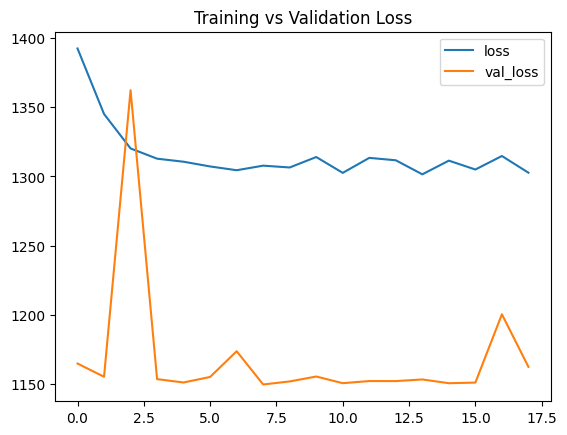

In [23]:
# Optional - Plot graph
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [24]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 121.1 MB/s eta 0:00:00


In [28]:
model.save("wine_model.h5")

In [30]:
import streamlit as st
import numpy as np

st.title("🍷 Wine Price Predictor")

points = st.slider("Wine Rating", 80, 100)

if st.button("Predict"):
    prediction = points * 2   # temporary logic
    st.write(f"Estimated Price: ${prediction}")

2026-04-16 09:58:53.270 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 09:58:53.870 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-16 09:58:53.872 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 09:58:53.874 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 09:58:53.876 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 09:58:53.876 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 09:58:53.877 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 09:58:53.878 Thread 'MainThread': mi